In [1]:
from brian2 import *
import matplotlib as plt
import numpy as np

Text(0, 0.5, 'voltage (mV)')

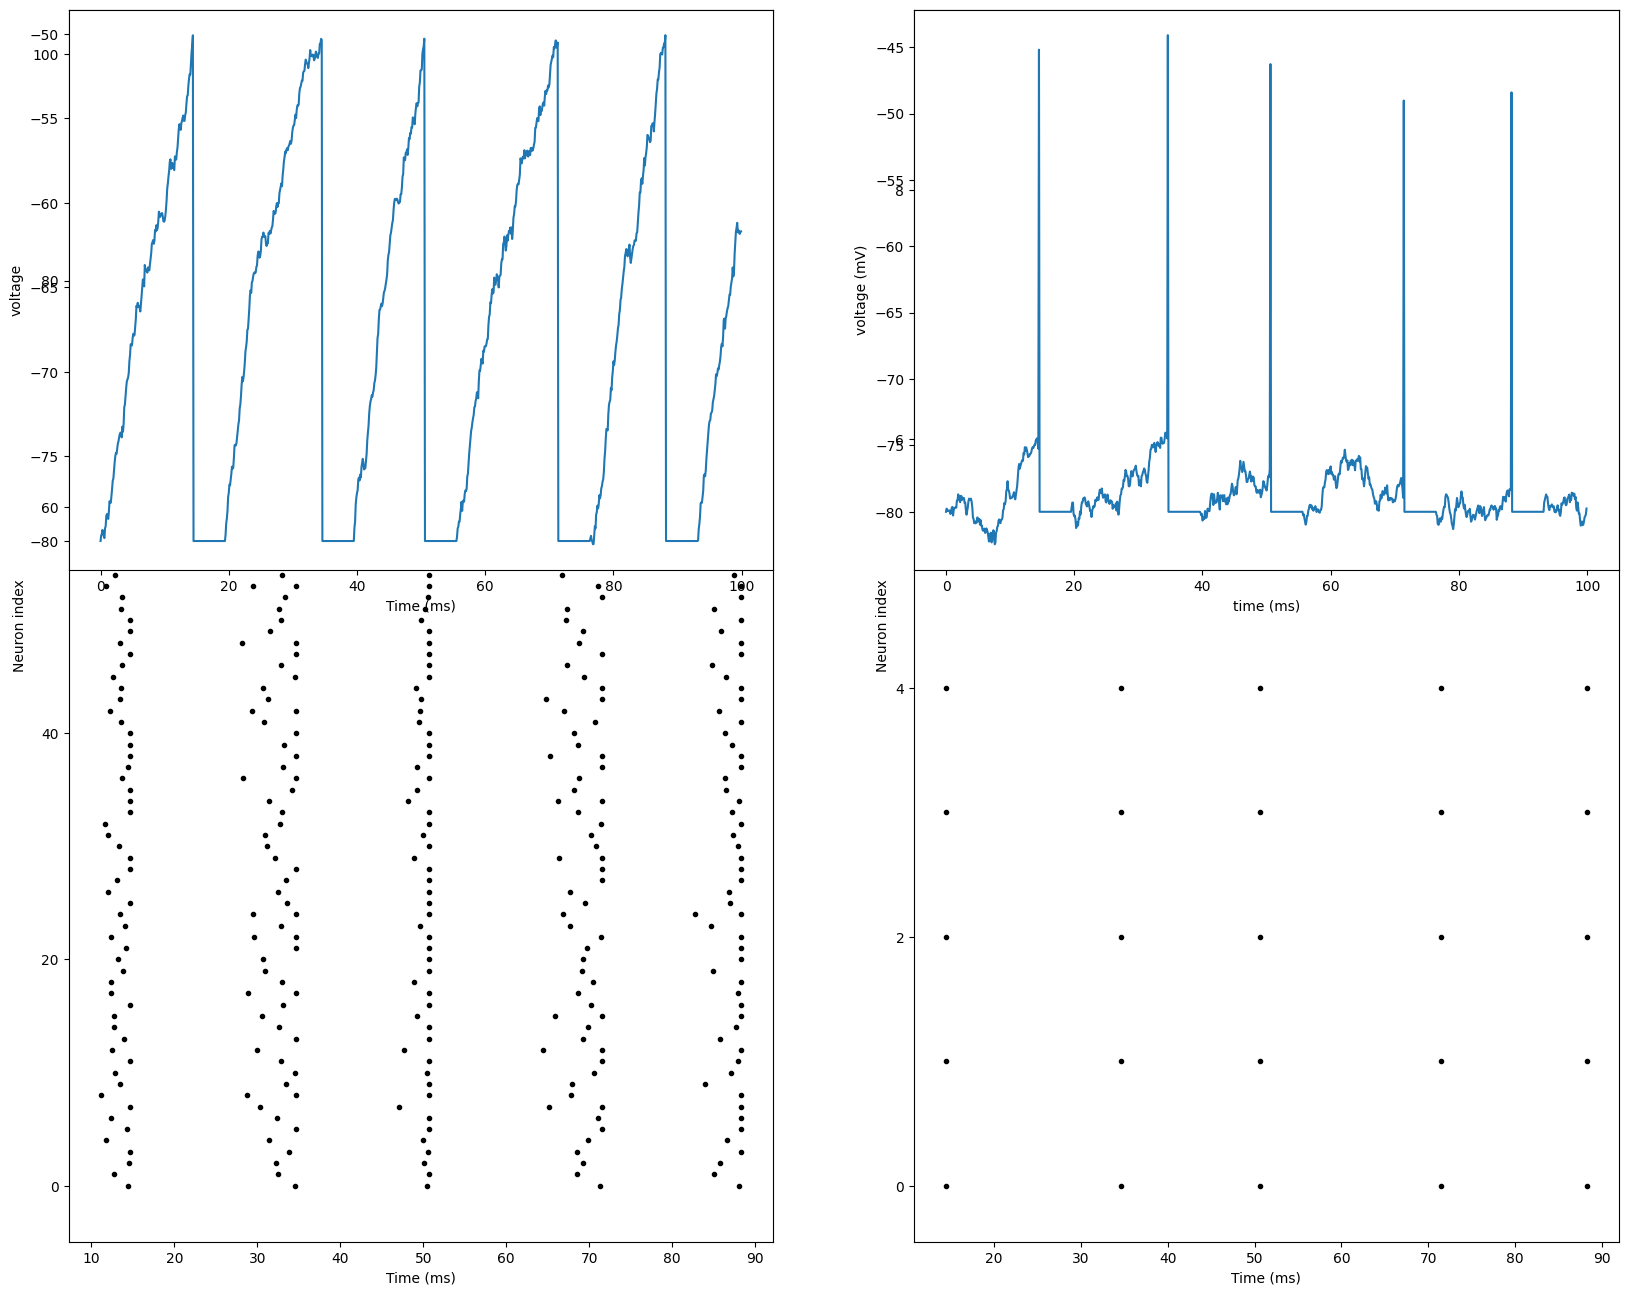

In [5]:
start_scope()


threshold = -50*mV
reset = -80*mV

Cm = 200 * pF       # membrane capacitance
gl = 10 * nS        # leak conductance
El = -70 * mV       # resting potential
w = 30*mV           # Synapse voltage
q = 50*mV

tau = 10*mS


eqs = '''
dv/dt = ((gl*(El - v)) + I)/Cm + sigma*xi/sqrt(ms) : volt (unless refractory)
I: amp
sigma:volt
'''


# Cortical neuron population
Cortical_neurons = NeuronGroup(
    100,
    model=eqs,
    reset='v = reset',
    threshold='v > threshold',
    refractory=5*ms,
    method='euler'
)

Thalamic_neurons = NeuronGroup(
    10, 
    model = eqs, 
    reset='v=reset', 
    threshold='v>threshold', 
    refractory = 5*ms, 
    method = 'euler')



# Monitors
CM = StateMonitor(Cortical_neurons, variables=['v'], record=True)
CS = SpikeMonitor(Cortical_neurons)

TM = StateMonitor(Thalamic_neurons, variables=['v'], record=True)
TS = SpikeMonitor(Thalamic_neurons)

SS = Synapses(Cortical_neurons, Thalamic_neurons, on_pre='v += w')
SS.connect(condition = 'j//10 == i')

BS = Synapses(Thalamic_neurons, Cortical_neurons, on_pre='v+=q')
BS.connect()

# Initial conditions
Cortical_neurons.v = '-80*mV'
Cortical_neurons.I = 0.5*nA
Cortical_neurons.sigma = 1*mV

Thalamic_neurons.v = '-80*mV'

Thalamic_neurons.I = 0*nA
Thalamic_neurons.sigma = 1*mV


# Simulation
run(100*ms)

# Raster plot
figure(figsize=(20,16))

subplot(1,2,1)
plot(CS.t/ms, CS.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')

subplot(1,2,2) 
plot(TS.t/ms, TS.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')

subplot(2,2,1)
plot(CM.t/ms, CM.v[0]/mV)
xlabel('Time (ms)')
ylabel('voltage')

subplot(2,2,2)
plot(TM.t/ms, TM.v[0]/mV)
xlabel('time (ms)')
ylabel('voltage (mV)')